In [1]:
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
df = pd.read_csv(
    "datasets/dataset_final.csv",
    engine="python",
    on_bad_lines="skip"
)
df.head()

,count,osm_id,lat,lon,pois_500m,same_category_500m,same_subcategory_500m,unique_subcategory_500m,services_500m,transport_500m,...,transport_type_highway,transport_type_public_transport,transport_type_railway,transport_subtype_bus_station,transport_subtype_bus_stop,transport_subtype_platform,transport_subtype_station,transport_subtype_stop_position,transport_subtype_taxi,transport_subtype_train_station_entrance
0,268.367796,0.269408,-0.251644,-0.169044,-0.064919,-0.064118,-0.04741,-0.061557,-0.058491,-0.046024,...,0,1,0,0,0,1,0,0,0,0
1,52.440458,0.269408,-0.251644,-0.169044,-0.064919,-0.064118,-0.04741,-0.061557,-0.058491,-0.046024,...,0,1,0,0,0,1,0,0,0,0
2,40.015808,0.269408,-0.251644,-0.169044,-0.064919,-0.064118,-0.04741,-0.061557,-0.058491,-0.046024,...,0,1,0,0,0,1,0,0,0,0
3,15.689651,0.269408,-0.251644,-0.169044,-0.064919,-0.064118,-0.04741,-0.061557,-0.058491,-0.046024,...,0,1,0,0,0,1,0,0,0,0
4,13.597078,0.269408,-0.251644,-0.169044,-0.064919,-0.064118,-0.04741,-0.061557,-0.058491,-0.046024,...,0,1,0,0,0,1,0,0,0,0


In [3]:
target_col = "pois_500m"
threshold = df[target_col].median()
y = (df[target_col] > threshold).astype(int)
X = df.drop(columns=[target_col])
y.value_counts(normalize=True)

pois_500m
0    0.989296
1    0.010704
Name: proportion, dtype: float64

Text(0, 0.5, 'pois_500m_high')

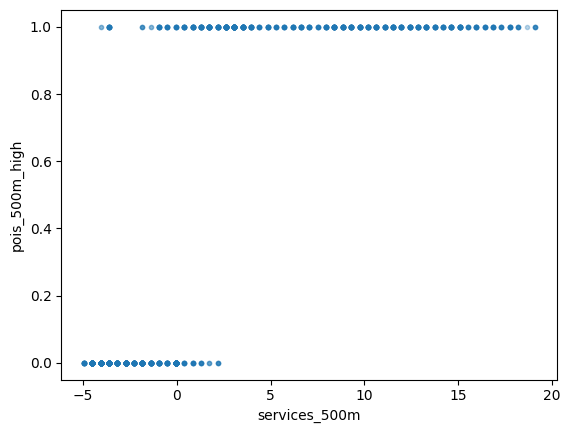

In [4]:
plt.scatter(df["services_500m"], y, marker='.', alpha=0.3)
plt.xlabel("services_500m")
plt.ylabel("pois_500m_high")

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, random_state=10
)

In [6]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [7]:
y_pred = model.predict(X_test)
y_pred[:5]

array([0, 0, 0, 0, 0])

In [8]:
model.predict_proba(X_test)[:5]

array([[9.99983841e-01, 1.61590000e-05],
       [9.99989279e-01, 1.07206199e-05],
       [9.99996092e-01, 3.90770128e-06],
       [9.99965460e-01, 3.45404634e-05],
       [9.99976116e-01, 2.38842568e-05]])

In [9]:
model.score(X_test, y_test)

0.999546485260771

In [10]:
confusion_matrix(y_test, y_pred)

array([[15246,     2],
       [    5,   182]])

In [11]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     15248
           1       0.99      0.97      0.98       187

    accuracy                           1.00     15435
   macro avg       0.99      0.99      0.99     15435
weighted avg       1.00      1.00      1.00     15435



In [12]:
model.coef_.shape

(1, 242)

In [13]:
model.intercept_

array([-0.33206529])